In [1]:
import numpy as np 
import pandas as pd 

ModuleNotFoundError: No module named 'numpy'

In [ ]:
train=pd.read_csv("Training.csv")
test=pd.read_csv("Testing.csv")

In [ ]:
train.head(10)

In [ ]:
test.head(10)

In [ ]:
train.shape
test.shape

In [ ]:
train = train.drop("Unnamed: 133", axis=1, errors='ignore')
train.head(10)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
5,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
6,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
7,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
8,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
9,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [ ]:
train.isna().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [ ]:
test.isna().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [ ]:
P = train[["prognosis"]]
X = train.drop(["prognosis"],axis=1)
Y = test.drop(["prognosis"],axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xvalid,ytrain,yvalid = train_test_split(X,P,test_size=0.2,random_state=1)

print(f"Train: {xtrain.shape}, {ytrain.shape}")
print(f"Validation: {xvalid.shape}, {yvalid.shape}")

Train: (3936, 132), (3936, 1)
Validation: (984, 132), (984, 1)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
rf= RandomForestClassifier(random_state=18)

In [ ]:
ytrain = np.array(ytrain).ravel()
model_rf = rf.fit(xtrain, ytrain) 
training_pred = model_rf.predict(xtrain) 
valid_pred = model_rf.predict(xvalid)

print("training accuracy is:", accuracy_score(ytrain , training_pred)) 
print("Testing accuracy is:", accuracy_score(yvalid , valid_pred))

training accuracy is: 1.0
Testing accuracy is: 1.0


[[33  0  0 ...  0  0  0]
 [ 0 23  0 ...  0  0  0]
 [ 0  0 23 ...  0  0  0]
 ...
 [ 0  0  0 ... 22  0  0]
 [ 0  0  0 ...  0 23  0]
 [ 0  0  0 ...  0  0 34]]


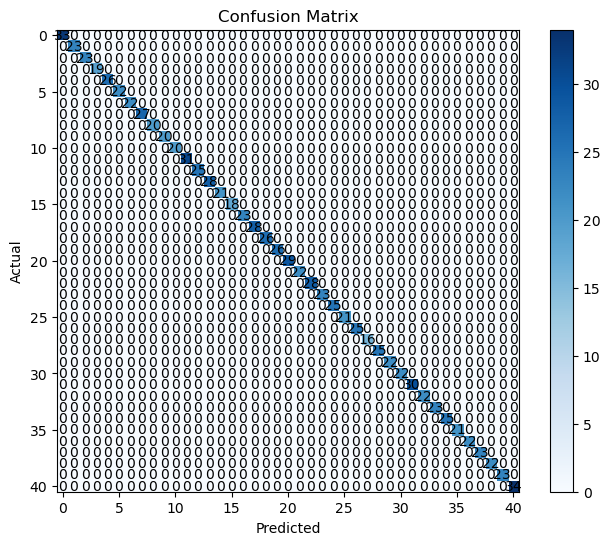

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(yvalid, valid_pred)

print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

[[33  0  0 ...  0  0  0]
 [ 0 23  0 ...  0  0  0]
 [ 0  0 23 ...  0  0  0]
 ...
 [ 0  0  0 ... 22  0  0]
 [ 0  0  0 ...  0 23  0]
 [ 0  0  0 ...  0  0 34]]


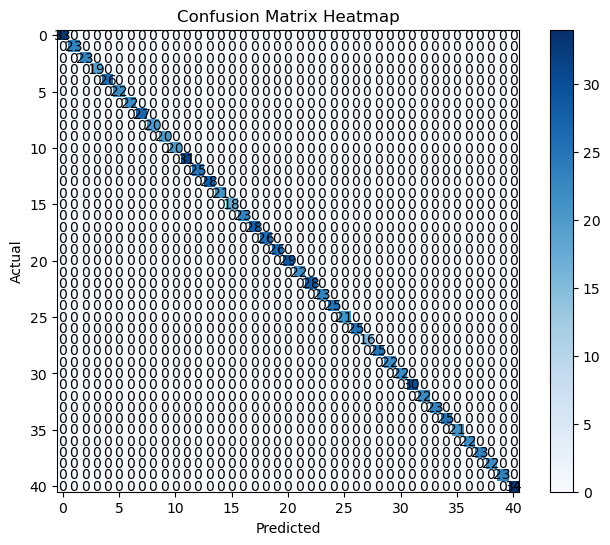

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
conf_matrix = confusion_matrix(yvalid, valid_pred)

print(conf_matrix)

# Plot
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Show values inside boxes
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.show()

In [ ]:
ytest = test['prognosis'] 
xtest = test.drop(['prognosis'], axis = 1)

In [ ]:
y_pred = model_rf.predict(xtest) 
print("Testing Data accuracy is:", accuracy_score(ytest, y_pred)*100)

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")


Testing Data accuracy is: 97.61904761904762


/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


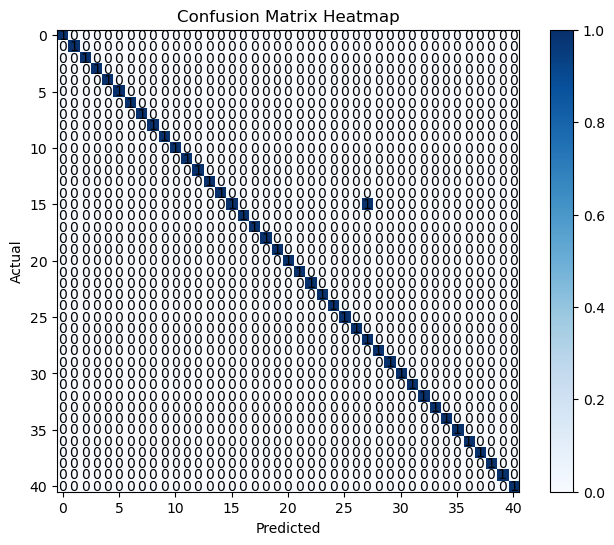

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

conf_matrix = confusion_matrix(ytest, y_pred)

print(conf_matrix)

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Numbers inside boxes
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.show()

In [ ]:
import numpy as np

# Define the new input with only three positions set to 1 and rest set to 0
new_input = [0] * 132
new_input[3] = 1
new_input[1] = 1
new_input[2] = 1

# Ensure new_input is a 2D array
new_input = np.array(new_input).reshape(1, -1)

# Predict the disease
pred1 = model_rf.predict(new_input)

# Print the predicted disease
print(f"The predicted disease is: {pred1[0]}")


/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


The predicted disease is: Fungal infection


In [ ]:
from sklearn import tree
dt=tree.DecisionTreeClassifier()
model_dt=dt.fit(xtrain,ytrain)
training_pred2=model_dt.predict(xtrain)
valid_pred2=model_dt.predict(xvalid)
print("Training accuracy is : ",accuracy_score(ytrain,training_pred2)*100)
print("Validation accuracy is :  ",accuracy_score(yvalid,valid_pred2)*100)

Training accuracy is :  100.0
Validation accuracy is :   100.0


In [ ]:
conf_dt=confusion_matrix(yvalid,valid_pred2)
print(conf_dt)

[[33  0  0 ...  0  0  0]
 [ 0 23  0 ...  0  0  0]
 [ 0  0 23 ...  0  0  0]
 ...
 [ 0  0  0 ... 22  0  0]
 [ 0  0  0 ...  0 23  0]
 [ 0  0  0 ...  0  0 34]]


In [ ]:
dt_pred = model_dt.predict(xtest)

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


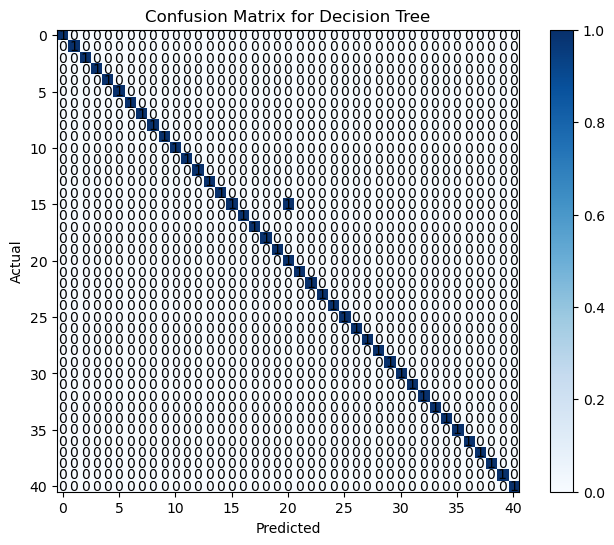

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_dt = confusion_matrix(ytest, dt_pred)

plt.figure(figsize=(8,6))
plt.imshow(conf_dt, cmap='Blues')

plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(conf_dt.shape[0]):
    for j in range(conf_dt.shape[1]):
        plt.text(j, i, conf_dt[i, j], ha='center', va='center')

plt.colorbar()
plt.show()


In [ ]:
ypred_dt=model_dt.predict(xtest)
print("Testing data Accuracy is : ",accuracy_score(ytest,ypred_dt)*100)

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")


Testing data Accuracy is :  97.61904761904762


In [ ]:
conf_dt_test=confusion_matrix(ytest,ypred_dt)
print(conf_dt_test)

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


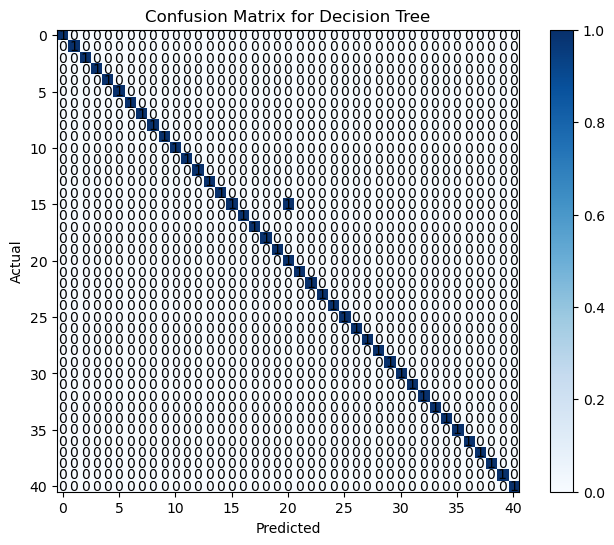

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(conf_dt_test, cmap='Blues')

plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(conf_dt_test.shape[0]):
    for j in range(conf_dt_test.shape[1]):
        plt.text(j, i, conf_dt_test[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [ ]:
import numpy as np

# Define the new input with only three positions set to 1 and rest set to 0
new_input = [0] * 132
new_input[3] = 1
new_input[1] = 1
new_input[2] = 1

# Ensure new_input is a 2D array
new_input = np.array(new_input).reshape(1, -1)

# Predict the disease
pred2 = model_dt.predict(new_input)

# Print the predicted disease
print(f"The predicted disease is: {pred2[0]}")

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


The predicted disease is: Fungal infection


In [ ]:
from sklearn.svm import SVC
svm=SVC()
model_svm=svm.fit(xtrain,ytrain)
training_pred3=model_svm.predict(xtrain)
valid_pred3=model_svm.predict(xvalid)

print("Training Accuracy is : ",accuracy_score(ytrain,training_pred3)*100)
print("Validating Accuracy is : ",accuracy_score(yvalid,valid_pred3)*100)

Training Accuracy is :  100.0
Validating Accuracy is :  100.0


In [ ]:
conf_svm=confusion_matrix(yvalid,valid_pred3)
print(conf_svm)

[[33  0  0 ...  0  0  0]
 [ 0 23  0 ...  0  0  0]
 [ 0  0 23 ...  0  0  0]
 ...
 [ 0  0  0 ... 22  0  0]
 [ 0  0  0 ...  0 23  0]
 [ 0  0  0 ...  0  0 34]]


In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(conf_svm,annot=True,fmt='d',cmap='Blues',xticklabels=model_dt.classes_,yticklabels=model_dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap for SVM Classifier")
plt.show()

<Figure size 2000x1500 with 0 Axes>

<class 'NameError'>: name 'sns' is not defined

In [ ]:
ypred_svm=model_svm.predict(xtest)
print("Testing Data Accuracy is : ",accuracy_score(ytest,ypred_svm)*100)

In [ ]:
conf_svm_test=confusion_matrix(ytest,ypred_svm)
print(conf_svm_test)

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(conf_svm_test,annot=True,fmt='d',cmap='Blues',xticklabels=model_dt.classes_,yticklabels=model_dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap for SVM Classifier")
plt.show()

In [ ]:
pred3 = model_svm.predict(new_input)

# Print the predicted disease
print(f"The predicted disease is: {pred3[0]}")

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


The predicted disease is: Fungal infection


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
model_nb=nb.fit(xtrain,ytrain)
training_pred4=model_nb.predict(xtrain)
valid_pred4=model_nb.predict(xvalid)

print("Training Accuracy Score is : ",accuracy_score(ytrain,training_pred4)*100)
print("Testing Accuracy Score is : ",accuracy_score(yvalid,valid_pred4)*100)

/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


Training Accuracy Score is :  100.0
Testing Accuracy Score is :  100.0


In [ ]:
conf_nb=confusion_matrix(yvalid,valid_pred4)
print(conf_nb)

[[33  0  0 ...  0  0  0]
 [ 0 23  0 ...  0  0  0]
 [ 0  0 23 ...  0  0  0]
 ...
 [ 0  0  0 ... 22  0  0]
 [ 0  0  0 ...  0 23  0]
 [ 0  0  0 ...  0  0 34]]


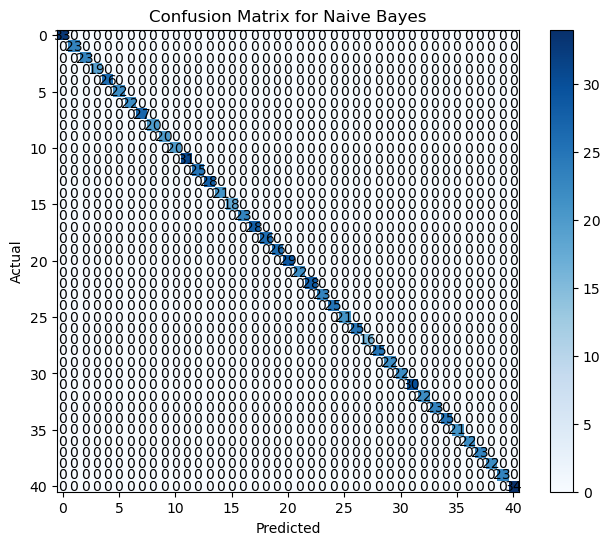

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(conf_nb, cmap='Blues')

plt.title("Confusion Matrix for Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(conf_nb.shape[0]):
    for j in range(conf_nb.shape[1]):
        plt.text(j, i, conf_nb[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [ ]:
ypred_nb=model_nb.predict(xtest)
print("Testing Accuracy is : ",accuracy_score(ytest,ypred_nb)*100)

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")


Testing Accuracy is :  100.0


In [ ]:
conf_nb_test=confusion_matrix(ytest,ypred_nb)
print(conf_nb_test)

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(conf_nb_test,annot=True,fmt='d',cmap='Blues',xticklabels=model_dt.classes_,yticklabels=model_dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap for Naive Bayes Classifier")
plt.show()

<Figure size 2000x1500 with 0 Axes>

<class 'NameError'>: name 'sns' is not defined

In [ ]:
pred4=model_nb.predict(new_input)
print(f"The predicted disease is: {pred4[0]}")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7,metric='minkowski',p=2)
model_knn=knn.fit(xtrain,ytrain)
training_pred5=model_knn.predict(xtrain)
valid_pred5=model_knn.predict(xvalid)

print("Training Accuracy is : ",accuracy_score(ytrain,training_pred5)*100)
print("Validating Accuracy is : ",accuracy_score(yvalid,valid_pred5)*100)

In [ ]:
conf_knn=confusion_matrix(yvalid,valid_pred5)
print(conf_knn)

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(conf_knn,annot=True,fmt='d',cmap='Blues',xticklabels=model_dt.classes_,yticklabels=model_dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap for KNN Classifier")
plt.show()

In [ ]:
ypred_knn=model_knn.predict(xtest)
print("Testing Accuracy is : ",accuracy_score(ytest,ypred_knn)*100)

In [ ]:
conf_knn_test=confusion_matrix(ytest,ypred_knn)
print(conf_knn_test)

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(conf_knn_test,annot=True,fmt='d',cmap='Blues',xticklabels=model_dt.classes_,yticklabels=model_dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap for KNN Classifier")
plt.show()

In [ ]:
pred5=model_knn.predict(new_input)
print(f"The predicted disease is: {pred5[0]}")

In [ ]:
from collections import Counter

# Assuming you have stored the validation accuracy of each model
model_accuracies = {
    'Random Forest': accuracy_score(yvalid, valid_pred),
    'SVM': accuracy_score(yvalid, model_svm.predict(xvalid)),
    'Naive Bayes': accuracy_score(yvalid, model_nb.predict(xvalid)),
    'Decision Tree': accuracy_score(yvalid, model_dt.predict(xvalid)),
    'KNN': accuracy_score(yvalid, model_knn.predict(xvalid))
}

# Function to predict the disease
def predict(new_input):

    # Predict the disease
    pred1 = model_rf.predict(new_input)
    pred2 = model_svm.predict(new_input)
    pred3 = model_nb.predict(new_input)
    pred4 = model_dt.predict(new_input)
    pred5 = model_knn.predict(new_input)

    # Print the predicted disease
    print(f"(Random Forest Algorithm) The predicted disease is: {pred1[0]}")
    print(f"(SVM Classifier Algorithm) The predicted disease is: {pred2[0]}")
    print(f"(Naive Bayes Classifier) The predicted disease is: {pred3[0]}")
    print(f"(Decision Tree) The predicted disease is: {pred4[0]}")
    print(f"(KNN Classifier) The predicted disease is: {pred5[0]}")

    # Aggregate predictions
    predictions = [pred1[0], pred2[0], pred3[0], pred4[0], pred5[0]]
    prediction_counts = Counter(predictions)
    most_common_prediction = prediction_counts.most_common(1)[0]

    # Check for majority
    if most_common_prediction[1] > 1:
        final_prediction = most_common_prediction[0]
        print(f"The Final Predicted disease is: {final_prediction}")
    else:
        # If no majority, choose the prediction from the most accurate model
        sorted_accuracies = sorted(model_accuracies.items(), key=lambda item: item[1], reverse=True)
        top_model = sorted_accuracies[0][0]
        if top_model == 'Random Forest':
            final_prediction = pred1[0]
        elif top_model == 'SVM':
            final_prediction = pred2[0]
        elif top_model == 'Naive Bayes':
            final_prediction = pred3[0]
        elif top_model == 'Decision Tree':
            final_prediction = pred4[0]
        elif top_model == 'KNN':
            final_prediction = pred5[0]
        
        print(f"The predictions were inconclusive. The final predicted disease based on the most accurate model ({top_model}) is: {final_prediction}")

# Define new input with only three positions set to 1 and rest set to 0
new_input = [0] * 132
new_input[10] = 1
new_input[78] = 1
new_input[3] = 1

# Ensure new_input is a 2D array
new_input = np.array(new_input).reshape(1, -1)
predict(new_input)
